In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error



appearances = pd.read_csv('appearances.csv')
players = pd.read_csv('players.csv')
valuations = pd.read_csv('player_valuations.csv')
transfers = pd.read_csv('transfers.csv')


top_leagues = ['GB1', 'IT1', 'ES1', 'L1', 'FR1']

# Pre-season valuations must be strictly earlier than this date
season_start_date = pd.Timestamp('2024-08-15')

# Players entering or leaving the top five after this date and before the prediction date are excluded
summer_window_end = pd.Timestamp('2024-09-01')

# Players must have accumulated at least 900 minutes by this date
# Target valuations must be strictly later than this date
prediction_date = pd.Timestamp('2025-05-25')

# Final date included in the target-valuation window
target_window_end = pd.Timestamp('2025-08-15')

## Dataset preparation

Duplicated player-date valuations: 0
Players actually excluded because they entered or left the top five after the summer window: 288

Missing performance values before aggregation:
0

Duplicated player-game appearances: 0

Players after league, season and 900-minute filters: 1537

Candidate players after sporting constraints: 1421

Target players excluded because they have no pre-season value: 2
Players with a pre-season value but no target: 54

Final dataset shape: (1359, 12)
Dataset shape after valuation-recency filter: (1359, 13)

Final missing-value summary: missing_count         0.0
missing_percentage    0.0
dtype: float64

Selected model features:
['age', 'appearances_count', 'minutes_played', 'goals_p90', 'assists_p90', 'prev_market_value_log', 'position', 'sub_position']

Training set shape: (1087, 8)
Test set shape: (272, 8)


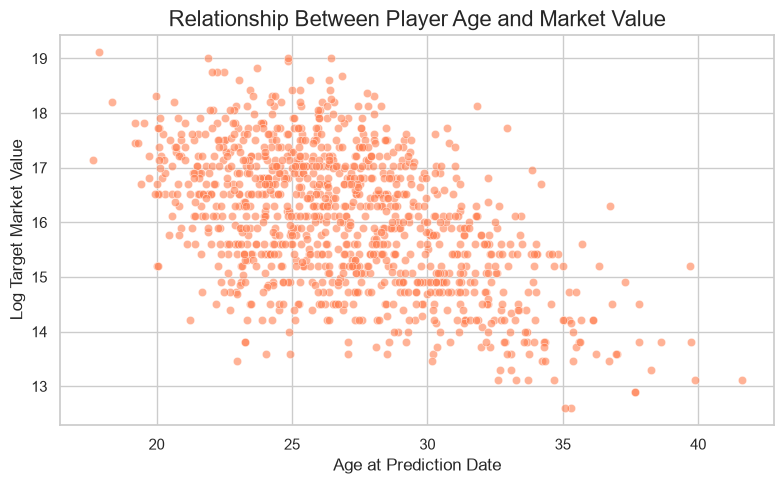

In [2]:
#VALUATIONS DATA PREPARATION

valuations['date'] = pd.to_datetime(valuations['date'], errors='coerce')
valuations_clean = valuations.dropna(subset=['player_id', 'date', 'market_value_in_eur'])

# Retain only valid (strictly positive) market values
valuations_clean = valuations_clean[valuations_clean['market_value_in_eur'] > 0].copy()

# Check for duplicated valuations for the same player on the same date
duplicated_valuations = valuations_clean.duplicated( subset=['player_id', 'date']).sum()
print( 'Duplicated player-date valuations:', duplicated_valuations)

# Extract the most recent market value right before the season starts
preseason_valuations = valuations_clean[valuations_clean['date'] < season_start_date].copy()
latest_pre_indices = preseason_valuations.groupby('player_id')['date'].idxmax()
latest_pre_val = preseason_valuations.loc[
    latest_pre_indices, ['player_id', 'date', 'market_value_in_eur']
].rename(columns={
    'date': 'prev_valuation_date',
    'market_value_in_eur': 'prev_market_value_in_eur'
}).reset_index(drop=True)


# Extract the first market valuation during the target window
target_window = valuations_clean[
    (valuations_clean['date'] > prediction_date)
    & (valuations_clean['date'] <= target_window_end)
].copy()
earliest_target_indices = target_window.groupby('player_id')['date'].idxmin()
target_values = target_window.loc[
    earliest_target_indices, ['player_id', 'date', 'market_value_in_eur']
].rename(columns={
    'date': 'target_valuation_date',
    'market_value_in_eur': 'target_market_value_in_eur'
}).reset_index(drop=True)

# APPEARANCES AND TRANSFER DATA FILTERING

appearances['date'] = pd.to_datetime(appearances['date'], errors='coerce')
appearances_clean = appearances.dropna(subset=['player_id', 'game_id', 'competition_id', 'date', 'minutes_played'])

# Filter appearances for the top 5 leagues within the selected season timeframe
app_filtered = appearances_clean[
    appearances_clean['competition_id'].isin(top_leagues) & 
    appearances_clean['date'].between(season_start_date, prediction_date, inclusive='both')
].copy()


# Identify players who moved in/out of the top 5 leagues after the summer transfer window
transfers['transfer_date'] = pd.to_datetime(transfers['transfer_date'], errors='coerce')
transfers_clean = transfers.dropna(subset=['player_id', 'transfer_date']).copy()
transfers_clean['from_club_id'] = pd.to_numeric(
    transfers_clean['from_club_id'], errors='coerce'
).astype('Int64')
transfers_clean['to_club_id'] = pd.to_numeric(
    transfers_clean['to_club_id'], errors='coerce'
).astype('Int64')

# Identify clubs participating in the top five leagues
top_five_club_ids = set(app_filtered['player_club_id'].dropna().astype(int).unique())

# Select transfers occurring after the summer window and before the cutoff
in_season_transfers = transfers_clean[
    (transfers_clean['transfer_date'] > summer_window_end) & 
    (transfers_clean['transfer_date'] <= prediction_date)
].copy()
in_season_transfers['from_top_five'] = in_season_transfers['from_club_id'].isin(top_five_club_ids)
in_season_transfers['to_top_five'] = in_season_transfers['to_club_id'].isin(top_five_club_ids)

# Drop players involved in cross-boundary mid-season transfers to ensure evaluation consistency
cross_boundary_transfers = in_season_transfers[
    in_season_transfers['from_top_five'] != in_season_transfers['to_top_five']
]

# Retain only transfers involving players who appear in the initially selected population
cross_boundary_transfers = cross_boundary_transfers[
    cross_boundary_transfers['player_id'].isin(
        app_filtered['player_id']
    )
].copy()
players_crossing_top_five_boundary = set(cross_boundary_transfers['player_id'])

print(
    'Players actually excluded because they entered or left the top five after the summer window:',
    len(players_crossing_top_five_boundary)
)

# Remove their appearances before calculating statistics.
app_filtered = app_filtered[~app_filtered['player_id'].isin(players_crossing_top_five_boundary)].copy()

# PERFORMANCE METRICS AGGREGATION

performance_missing_summary = (app_filtered[['minutes_played','goals','assists']].isna().sum())
print('\nMissing performance values before aggregation:')
print(performance_missing_summary.sum())

duplicate_appearances = app_filtered.duplicated(subset=['player_id', 'game_id']).sum()
print('\nDuplicated player-game appearances:', duplicate_appearances)

# Group statistics per player and calculate per-90-minute metrics.
stats = (
    app_filtered
    .groupby('player_id', as_index=False)
    .agg(
        appearances_count=('game_id', 'count'),
        minutes_played=('minutes_played', 'sum'),
        total_goals=('goals', 'sum'),
        total_assists=('assists', 'sum')
    )
)

# Retain only players with at least 900 minutes played.
stats = stats[stats['minutes_played'] >= 900].copy()

# Create per-90-minute performance features.
stats['goals_p90'] = (stats['total_goals'] / stats['minutes_played']) * 90
stats['assists_p90'] = (stats['total_assists'] / stats['minutes_played']) * 90

stats = stats.drop(columns=['total_goals', 'total_assists'])

print('\nPlayers after league, season and 900-minute filters:',len(stats))

# CLEAN PLAYER INFORMATION

player_columns = ['player_id', 'date_of_birth', 'position', 'sub_position']
players_clean = players[player_columns].copy()
players_clean['date_of_birth'] = pd.to_datetime(players_clean['date_of_birth'], errors='coerce')

# Exclude goalkeepers.
players_clean = players_clean.dropna(subset=['player_id', 'position']).copy()
players_clean = players_clean[players_clean['position'] != 'Goalkeeper'].copy()

# Calculate age at the prediction date.
players_clean['age'] = (prediction_date - players_clean['date_of_birth']).dt.days / 365.2425
players_clean = players_clean.drop(columns=['date_of_birth'])

# Missing sub-positions are represented explicitly.
players_clean['sub_position'] = players_clean['sub_position'].fillna('Unknown')

# Merge stats with player demographic data.
candidate_df = stats.merge(players_clean, on='player_id', how='inner', validate='one_to_one')

print('\nCandidate players after sporting constraints:', len(candidate_df))

# CREATE THE FINAL SUPERVISED-LEARNING DATASET

candidate_df['has_preseason_value'] = (
    candidate_df['player_id'].isin(latest_pre_val['player_id'])
)

candidate_df['has_target'] = (
    candidate_df['player_id'].isin(target_values['player_id'])
)

# Isolate players missing either the initial or the target valuation
players_without_initial_value = candidate_df[
    candidate_df['has_target'] & ~candidate_df['has_preseason_value']
].copy()

players_without_target = candidate_df[
    candidate_df['has_preseason_value'] & ~candidate_df['has_target']
].copy()

print(
    '\nTarget players excluded because they have no pre-season value:',
    len(players_without_initial_value)
)

print('Players with a pre-season value but no target:',len(players_without_target))

# CREATE THE FINAL SUPERVISED-LEARNING DATASET

# Retain only players with both valuations and merge all required features
eligible_player_ids = set(latest_pre_val['player_id']).intersection(target_values['player_id'])

df = (
    candidate_df[candidate_df['player_id'].isin(eligible_player_ids)]
    .drop(columns=['has_preseason_value', 'has_target'])
    .merge(latest_pre_val, on='player_id', how='inner', validate='one_to_one')
    .merge(target_values, on='player_id', how='inner', validate='one_to_one')
)

print('\nFinal dataset shape:', df.shape)

assert (df['prev_market_value_in_eur'] > 0).all()

assert (df['target_market_value_in_eur'] > 0).all()

assert df['player_id'].is_unique

# Ensure the pre-season baseline valuation is not older than 365 days.
df['days_since_previous_valuation'] = (season_start_date - df['prev_valuation_date']).dt.days
df = df[df['days_since_previous_valuation'] <= 365].copy()

print('Dataset shape after valuation-recency filter:', df.shape)

# CREATE LOG-TRANSFORMED VARIABLES

df['prev_market_value_log'] = np.log1p(df['prev_market_value_in_eur'])
df['target_market_value_log'] = np.log1p(df['target_market_value_in_eur'])

# CHECK FINAL MISSING VALUES

missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percentage': df.isna().mean() * 100
})

print('\nFinal missing-value summary:', missing_summary.sum())

# DEFINE FEATURES AND TARGET

numerical_features = [
    'age', 'appearances_count', 'minutes_played', 
    'goals_p90', 'assists_p90', 'prev_market_value_log'
]
categorical_features = ['position', 'sub_position']

feature_columns = numerical_features + categorical_features

X = df[feature_columns].copy()
y = df['target_market_value_log'].copy()

print('\nSelected model features:')
print(X.columns.tolist())

# SPLIT THE DATASET

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Store a copy of the training set for Exploratory Data Analysis
train_df = X_train.copy()
train_df['target_market_value_log'] = y_train

print('\nTraining set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

# DEFINE THE PREPROCESSING PIPELINE

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

# EXPLORATORY DATA ANALYSIS (EDA)

# Visualize the relationship between Player Age and Post-Season Market Value.
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_df,
    x='age',
    y='target_market_value_log',
    alpha=0.6,
    color='coral'
)

plt.title('Relationship Between Player Age and Market Value', fontsize=16)
plt.xlabel('Age at Prediction Date', fontsize=12)
plt.ylabel('Log Target Market Value', fontsize=12)

plt.tight_layout()
plt.show()

## Exploratory analysis and feature selection

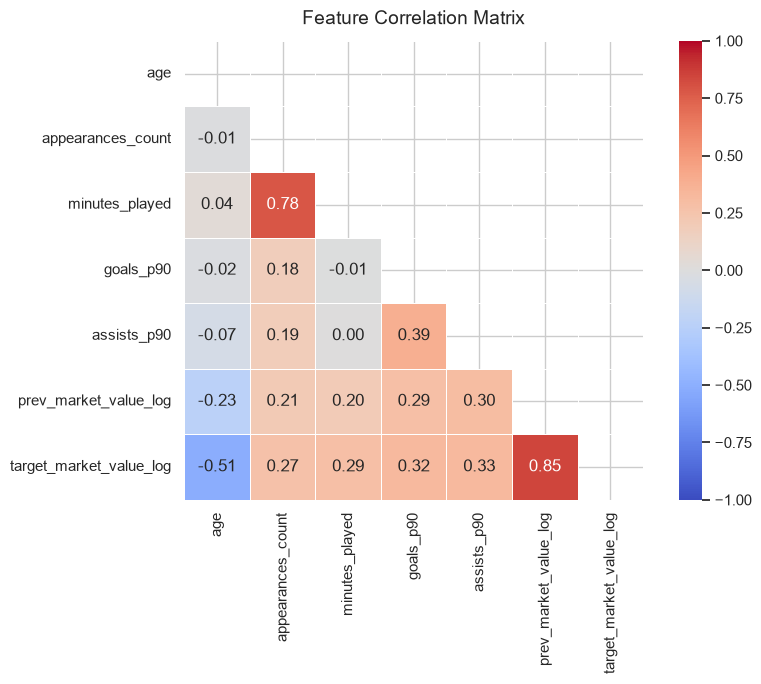

In [3]:
# Correlation Heatmap
corr_cols = [
    'age', 'appearances_count', 'minutes_played',
    'goals_p90', 'assists_p90', 'prev_market_value_log', 'target_market_value_log'
]
corr_matrix = train_df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Model validation

In [4]:
#Configuration of 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
#Pipeline for Ridge Regression Model
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

#RMSE Calculation on 5-fold Cross-Validation
ridge_cv_scores = cross_val_score(
    ridge_pipeline, X_train, y_train,
    cv=kf, scoring='neg_root_mean_squared_error', error_score='raise'
)
ridge_rmse = -ridge_cv_scores.mean()
ridge_rmse_std = ridge_cv_scores.std()

print(f"Average RMSE (Ridge): {ridge_rmse:.4f} +/- {ridge_rmse_std:.4f}")

Average RMSE (Ridge): 0.4457 +/- 0.0299


In [6]:
#Pipeline for Random Forest Regressor Model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

#RMSE Calculation on 5-fold Cross-Validation
rf_cv_scores = cross_val_score(
    rf_pipeline, X_train, y_train,
    cv=kf, scoring='neg_root_mean_squared_error', error_score='raise'
)
rf_rmse = -rf_cv_scores.mean()
rf_rmse_std = rf_cv_scores.std()

print(f"Average RMSE (Random Forest): {rf_rmse:.4f} +/- {rf_rmse_std:.4f}")

Average RMSE (Random Forest): 0.4099 +/- 0.0237


## Model selection and final evaluation

In [7]:
# Selection of the best model based on average RMSE from cross-validation
validation_rmse = {
    'Ridge': ridge_rmse,
    'Random Forest': rf_rmse
}
pipelines = {
    'Ridge': ridge_pipeline,
    'Random Forest': rf_pipeline
}
best_model_name = min(validation_rmse, key=validation_rmse.get)
best_pipeline = pipelines[best_model_name]

# Train the best model on the entire training set
best_pipeline.fit(X_train, y_train)

# Evaluate the model on the training and test sets in log scale
train_pred = best_pipeline.predict(X_train)
y_pred = best_pipeline.predict(X_test)
final_train_rmse_log = np.sqrt(mean_squared_error(y_train, train_pred))
final_test_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))

# Convert predictions and true values back to the original scale (euro) for final evaluation
y_pred_eur = np.maximum(np.expm1(y_pred), 0)
y_test_eur = np.expm1(y_test)
final_test_rmse_eur = np.sqrt(mean_squared_error(y_test_eur, y_pred_eur))
final_test_mae_eur = np.mean(np.abs(y_test_eur - y_pred_eur))
median_absolute_percentage_error = np.median(
    np.abs((y_test_eur - y_pred_eur) / y_test_eur)
) * 100

# Baseline: predicting the pre-season market value is the same as the post-season value
baseline_pred_log = X_test['prev_market_value_log'].to_numpy()
baseline_pred_eur = np.expm1(baseline_pred_log)
baseline_rmse_eur = np.sqrt(mean_squared_error(y_test_eur, baseline_pred_eur))
baseline_mae_eur = np.mean(np.abs(y_test_eur - baseline_pred_eur))

print(f'Selected model: {best_model_name}')
print(f'Training RMSE (log scale): {final_train_rmse_log:.4f}')
print(f'Final Test RMSE (log scale): {final_test_rmse_log:.4f}')
print(f'Final Test RMSE (euros): €{final_test_rmse_eur:,.2f}')
print(f'Final Test MAE (euros): €{final_test_mae_eur:,.2f}')
print(f'Median Absolute Percentage Error: {median_absolute_percentage_error:.2f}%')
print(f'Baseline RMSE (euros): €{baseline_rmse_eur:,.2f}')
print(f'Baseline MAE (euros): €{baseline_mae_eur:,.2f}')

Selected model: Random Forest
Training RMSE (log scale): 0.1522
Final Test RMSE (log scale): 0.4090
Final Test RMSE (euros): €7,716,723.67
Final Test MAE (euros): €4,487,798.45
Median Absolute Percentage Error: 23.23%
Baseline RMSE (euros): €9,438,637.08
Baseline MAE (euros): €5,600,827.21
